<a href="https://colab.research.google.com/github/Viktoriia-code26/goit_data_ML_Hw_06/blob/main/HwML_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [20]:
# Загрузка данных
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import os

zip_path = "/content/drive/MyDrive/data.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Архив распакован!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Архив распакован!


In [21]:
print(os.listdir("/content/data/data"))

['data_2d.csv', 'mnist.csv']


In [22]:
import pandas as pd


mnist_df = pd.read_csv("/content/data/data/mnist.csv", header=None)
data_2d_df = pd.read_csv("/content/data/data/data_2d.csv", header=None)

print("MNIST:", mnist_df.shape)
print("2D data:", data_2d_df.shape)

display(mnist_df.head())
display(data_2d_df.head())


MNIST: (500, 785)
2D data: (200, 3)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0,1,2
0,0.0,-0.768716,0.460860
1,0.0,2.687848,2.366961
2,0.0,-0.201379,0.470430
3,0.0,0.608496,1.225400
4,0.0,-0.082282,1.137218


In [23]:
print("MNIST columns:", mnist_df.columns.tolist())
print("2D columns:", data_2d_df.columns.tolist())

MNIST columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,

In [24]:
X = data_2d_df.iloc[:, 1:3].values

print(X.shape)
print(X[:5])

(200, 2)
[[-0.76871646  0.46086031]
 [ 2.68784756  2.36696066]
 [-0.20137936  0.47042993]
 [ 0.60849568  1.22540003]
 [-0.0822819   1.13721812]]


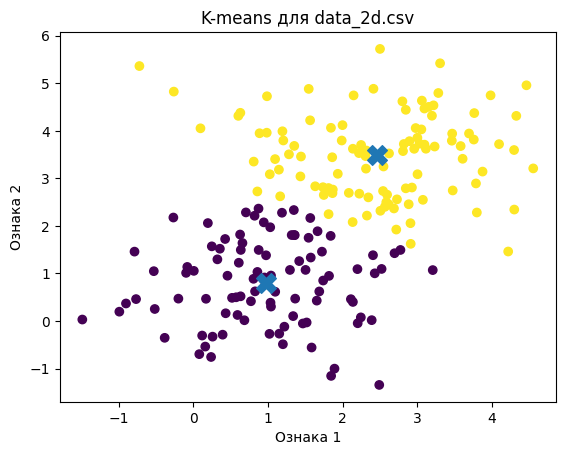

In [25]:
k = 2

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Ознака 1")
plt.ylabel("Ознака 2")
plt.title("K-means для data_2d.csv")
plt.show()

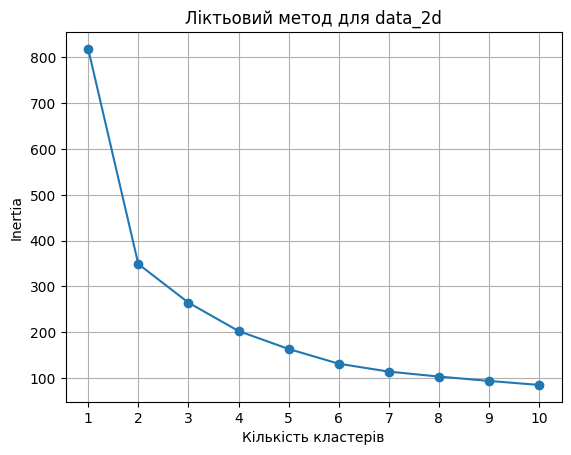

In [26]:
inertias = []

K = range(1, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(K, inertias, marker="o")
plt.xlabel("Кількість кластерів")
plt.ylabel("Inertia")
plt.title("Ліктьовий метод для data_2d")
plt.xticks(K)
plt.grid()
plt.show()

За результатами ліктьового методу оптимальною кількістю кластерів є k = 2, оскільки після трьох кластерів зменшення значення Inertia стає незначним, а крива помітно вирівнюється.

In [27]:
kmeans.labels_

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1], dtype=int32)

In [28]:
kmeans.cluster_centers_

array([[0.97799508, 0.80217417],
       [2.46540572, 3.48660748]])

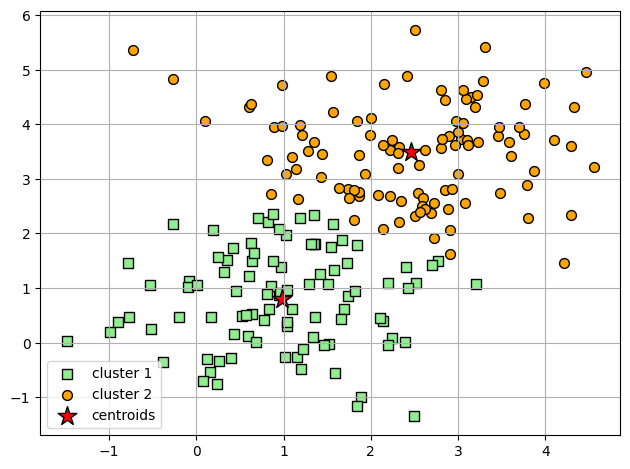

In [37]:
# plot the 3 clusters
plt.scatter(
    X[clusters == 0, 0], X[clusters == 0, 1],
    s=50, c='lightgreen',
    marker='s', edgecolor='black',
    label='cluster 1'
)
plt.scatter(
    X[clusters == 1, 0], X[clusters == 1, 1],
    s=50, c='orange',
    marker='o', edgecolor='black',
    label='cluster 2'
)

#plot the centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    s=200, marker='*',
    c='red', edgecolor='black',
    label='centroids'
)

plt.legend(scatterpoints=1)
plt.grid()
plt.tight_layout()
plt.show()
#

# Mnist

In [30]:
X_mnist = mnist_df.iloc[:, 1:].values

print(X_mnist.shape)

(500, 784)


In [31]:
k = 3
kmeans_mnist = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters_mnist = kmeans_mnist.fit_predict(X_mnist)

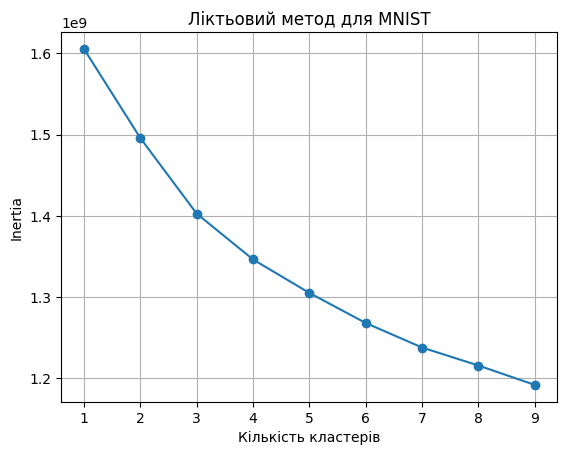

In [32]:
inertias = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_mnist)
    inertias.append(km.inertia_)

plt.plot(range(1,10), inertias, marker='o')
plt.xlabel("Кількість кластерів")
plt.ylabel("Inertia")
plt.title("Ліктьовий метод для MNIST")
plt.grid(True)
plt.show()

За результатами ліктьового методу оптимальною кількістю кластерів є k = 3, оскільки після 3 кластерів зменшення значення Inertia стає незначним.

In [38]:
kmeans_mnist.labels_

array([1, 0, 2, 0, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 2, 0, 1, 1, 0, 1, 2, 0,
       1, 0, 1, 0, 1, 1, 0, 2, 2, 2, 0, 0, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2,
       2, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2,
       1, 1, 0, 0, 1, 0, 0, 2, 2, 2, 0, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 0,
       1, 2, 0, 2, 2, 0, 2, 1, 2, 2, 0, 1, 1, 0, 0, 1, 1, 1, 0, 2, 1, 1,
       0, 2, 2, 1, 2, 2, 1, 1, 1, 1, 0, 2, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 2, 0, 2, 0, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 2, 1, 1, 2, 0,
       2, 0, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 0, 0, 2, 2,
       2, 0, 2, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2,
       1, 0, 0, 0, 2, 2, 2, 2, 1, 0, 0, 1, 1, 2, 1, 2, 1, 0, 0, 2, 2, 0,
       1, 0, 0, 1, 2, 0, 0, 2, 2, 2, 2, 2, 0, 1, 2, 1, 2, 2, 1, 2, 0, 0,
       0, 1, 2, 2, 0, 2, 1, 2, 1, 2, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 1, 2,
       2, 2, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 2, 0, 1, 2, 2, 1, 2,
       2, 1, 2, 0, 1, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2,

In [39]:
kmeans_mnist.cluster_centers_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

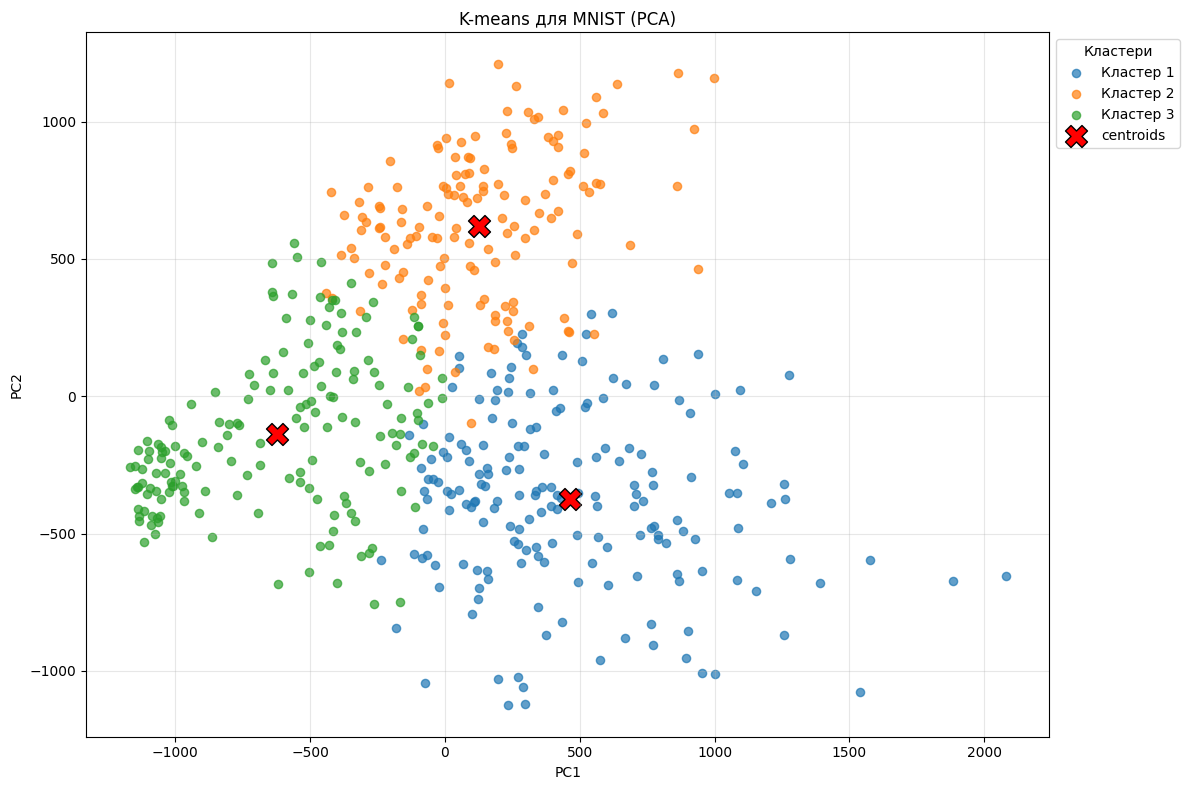

In [42]:
# Уменьшение размерности для визуализации
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_mnist)

# Переводим центры кластеров в пространство РСА
centers_pca = pca.transform(kmeans_mnist.cluster_centers_)

# Рисуем каждый класс отдельно
k = 3
plt.figure(figsize=(12,8))
for cluster_number in range(k):
  mask = clusters_mnist == cluster_number
  plt.scatter(
      X_pca[mask, 0],
      X_pca[mask, 1],
      s=35,
      alpha=0.7,
      label=f"Кластер {cluster_number + 1}"
  )

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=250,
    c="red",
    edgecolor="black",
    label="centroids"
)

plt.title("K-means для MNIST (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.legend(
    title = "Кластери",
    loc="upper left",
    bbox_to_anchor=(1,1)
)
plt.tight_layout()
plt.show()

Після застосування алгоритму PCA дані MNIST були зведені до двох головних компонент, що дозволило візуалізувати результати кластеризації K-means. Отримані кластери частково відокремлені один від одного, однак між деякими з них спостерігається перекриття, що пояснюється схожістю окремих рукописних цифр та втратою частини інформації під час зменшення розмірності.

# Висновок.
У ході виконання роботи було застосовано алгоритм K-means для кластеризації двох наборів даних: двовимірного датасету та MNIST. Для визначення оптимальної кількості кластерів було використано ліктьовий метод. Для набору даних MNIST попередньо було виконано зменшення розмірності за допомогою алгоритму PCA до двох головних компонент, що дозволило візуалізувати результати кластеризації. Отримані результати показали, що алгоритм K-means успішно розділяє дані на кластери, хоча для MNIST між окремими кластерами спостерігається часткове перекриття через схожість рукописних цифр та втрату частини інформації під час зменшення розмірності. Таким чином, поставлену мету роботи було досягнуто.